# Lasso Regression for Feature Selection and Ridge Regression Comparison

**Dataset:** Advertising Dataset  
**Features:** TV, Radio, Newspaper  
**Target:** Sales


## Objective
To implement **Lasso Regression** for feature selection and compare its performance with **Ridge Regression** using the Advertising dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score


## 1. Load the Dataset

Keep `Advertising.csv` in the same folder as this notebook.

In [5]:
df = pd.read_csv('Advertising.csv')

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [6]:
print('Shape:', df.shape)
print('\nColumns:', list(df.columns))
print('\nMissing values:')
print(df.isnull().sum())

Shape: (200, 4)

Columns: ['TV', 'Radio', 'Newspaper', 'Sales']

Missing values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


## 2. Select Features and Target

In [7]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

print('Features:', X.columns.tolist())
print('Target: Sales')

Features: ['TV', 'Radio', 'Newspaper']
Target: Sales


## 3. Split the Dataset

80% data is used for training and 20% for testing.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 160
Testing samples: 40


## 4. Standardize the Features

Standardization is used because Lasso and Ridge apply regularization to the coefficients.

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Lasso Regression

Lasso uses **L1 regularization**. It can make some coefficients exactly zero, which helps in feature selection.

In [10]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)

lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

print('Lasso MSE :', round(lasso_mse, 4))
print('Lasso RMSE:', round(lasso_rmse, 4))
print('Lasso R2  :', round(lasso_r2, 4))

Lasso MSE : 2.9301
Lasso RMSE: 1.7118
Lasso R2  : 0.9052


## 6. Lasso Feature Selection

A coefficient equal to zero means that Lasso has removed that feature from the model.

In [11]:
lasso_coefficients = pd.Series(lasso.coef_, index=X.columns)

print('Lasso Coefficients:')
print(lasso_coefficients)

selected_features = lasso_coefficients[lasso_coefficients != 0].index.tolist()
removed_features = lasso_coefficients[lasso_coefficients == 0].index.tolist()

print('\nSelected features:', selected_features)
print('Removed features:', removed_features if removed_features else 'None')

Lasso Coefficients:
TV           4.492181
Radio        1.423016
Newspaper    0.015662
dtype: float64

Selected features: ['TV', 'Radio', 'Newspaper']
Removed features: None


## 7. Ridge Regression

Ridge uses **L2 regularization**. It reduces the size of coefficients but normally does not make them exactly zero.

In [12]:
ridge = Ridge(alpha=0.1)
ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print('Ridge MSE :', round(ridge_mse, 4))
print('Ridge RMSE:', round(ridge_rmse, 4))
print('Ridge R2  :', round(ridge_r2, 4))

Ridge MSE : 2.9084
Ridge RMSE: 1.7054
Ridge R2  : 0.9059


## 8. Compare Lasso and Ridge Coefficients

In [13]:
comparison = pd.DataFrame({
    'Feature': X.columns,
    'Lasso Coefficient': lasso.coef_,
    'Ridge Coefficient': ridge.coef_
})

comparison

,Feature,Lasso Coefficient,Ridge Coefficient
0,TV,4.492181,4.584385
1,Radio,1.423016,1.488924
2,Newspaper,0.015662,0.088270


## 9. Compare Model Performance

In [14]:
results = pd.DataFrame({
    'Model': ['Lasso Regression', 'Ridge Regression'],
    'MSE': [lasso_mse, ridge_mse],
    'RMSE': [lasso_rmse, ridge_rmse],
    'R2 Score': [lasso_r2, ridge_r2]
})

results.round(4)

,Model,MSE,RMSE,R2 Score
0,Lasso Regression,2.9301,1.7118,0.9052
1,Ridge Regression,2.9084,1.7054,0.9059


## 10. Visualize Actual vs Predicted Sales

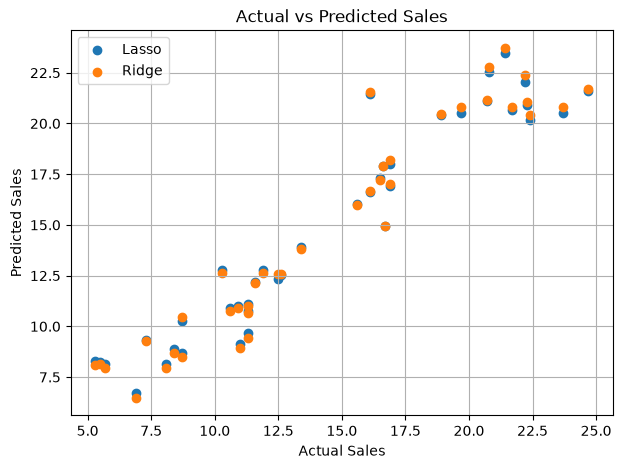

In [15]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, lasso_pred, label='Lasso')
plt.scatter(y_test, ridge_pred, label='Ridge')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.legend()
plt.grid(True)
plt.show()

## 11. Conclusion

- **Lasso Regression** uses L1 regularization and can perform feature selection by reducing some coefficients to zero.
- **Ridge Regression** uses L2 regularization and keeps the features while shrinking their coefficients.
- The model performance can be compared using **MSE, RMSE and R² score**.
- The features with non-zero Lasso coefficients are the features selected by Lasso for this dataset and chosen alpha value.
- The exact selected features and performance values are displayed above after running the notebook.